In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

In [2]:
# Loading Dataset
dermatology = fetch_ucirepo(id=33)

X = dermatology.data.features.copy()
y = dermatology.data.targets.copy()

print("Shape of X: ", X.shape)
print("Shape of y: ", y.shape)

Shape of X:  (366, 34)
Shape of y:  (366, 1)


In [30]:
actual_y_label = ["psoriasis", "seboreic dermatitis", "lichen planus", "pityriasis rosea", "cronic dermatitis", "pityriasis rubra pilaris"]

In [ ]:
# Making the target 1-D
y = y.iloc[:,0]

In [18]:
# Encoding target labels

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [19]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=48,
    stratify=y
)

In [ ]:
# Model

model = XGBClassifier(
    n_estimators=200,#-------------number of trees
    learning_rate=0.1,
    max_depth=5,    #--------------max depth of each tree
    subsample=0.9,  #--------------percentage of data used per tree
    colsample_bytree=0.9,#---------percentaeg of features used per tree
    objective="multi:softprob",#---multiclass classification
    num_class=len(np.unique(y)),#--number of classes
    eval_metric="mlogloss",#-------loss function
    random_state=48
)

In [14]:
# Full Pipeline

pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", model)
])

In [20]:
# Training Model

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, gpu_id=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, n_estimators=200, n_jobs=None,
              num_class=6, num_parallel_tree=None, objective='multi:softprob', ...)

In [21]:
# Predictions
y_preds = model.predict(X_test)

In [31]:
# Evaluation
acc = accuracy_score(y_test, y_preds)
prec = precision_score(y_test, y_preds, average="weighted", zero_division=0)
rec = recall_score(y_test, y_preds, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_preds, average="weighted", zero_division=0)

print("\n================================")
print("Results")
print("================================")
print(f"Accuracy :  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_preds,
    target_names=actual_y_label,
    zero_division=0
))


Results
Accuracy :  0.9595
Precision: 0.9596
Recall: 0.9595
F1-score: 0.9586

Classification Report:
                          precision    recall  f1-score   support

               psoriasis       0.96      1.00      0.98        23
     seboreic dermatitis       0.91      0.83      0.87        12
           lichen planus       0.94      1.00      0.97        15
        pityriasis rosea       1.00      0.90      0.95        10
       cronic dermatitis       1.00      1.00      1.00        10
pityriasis rubra pilaris       1.00      1.00      1.00         4

                accuracy                           0.96        74
               macro avg       0.97      0.96      0.96        74
            weighted avg       0.96      0.96      0.96        74



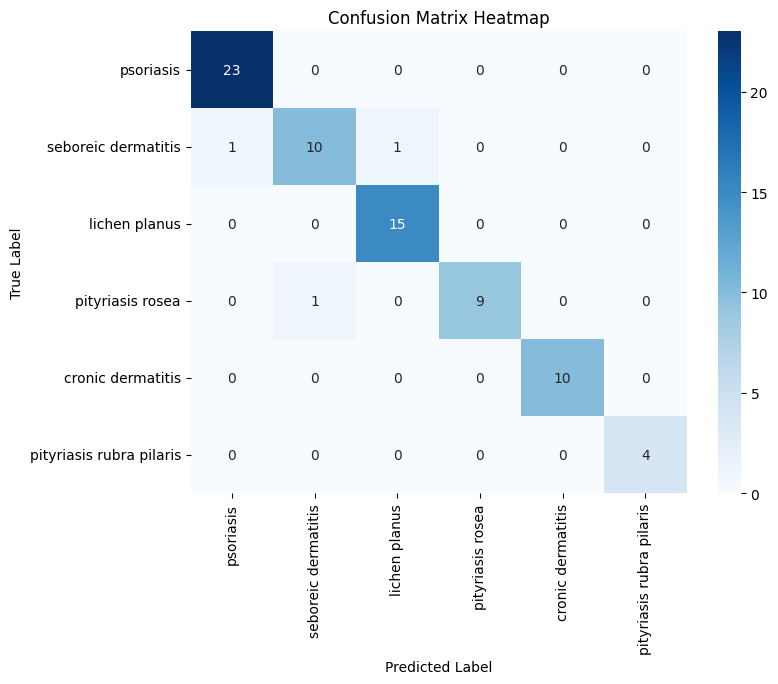

In [ ]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True, #-----------------shows actual value inside blocks
    fmt='d',    #-----------------int
    cmap='Blues',#----------------map colour
    xticklabels=actual_y_label,
    yticklabels=actual_y_label
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")

plt.show()